## QueryPi Results Analysis
Visual analysis of experiment results across all three models and both conditions.
Run `evaluate_results.py` first to generate the scored JSON files. These files are then manually reviewed and updated.

In [2]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "scored_results"

# These are the scored JSON files generated by evaluate_results.py
FILES = ["tinyllama_scored.json", "gemma_scored.json", "qwen_scored.json"]

# Load each scored results file into a dictionary keyed by model name
all_data = {}
for filename in FILES:
    filepath = os.path.join(RESULTS_DIR, filename)
    if not os.path.exists(filepath):
        print(f"Missing: {filepath} — run evaluate_results.py first")
        continue
    with open(filepath) as f:
        data = json.load(f)
    all_data[data["model"]] = data

# Extract model names
models = list(all_data.keys())
print("Loaded:", models)

Loaded: ['TinyLlama 1.1B', 'Gemma 2B', 'Qwen 2.5 3B']


## 1. Average Response Latency and RAM Usage

In [3]:
# Calculate and print average response latency and peak memory usage
# for each model under both conditions

print(f"{'Model':<20} {'Lat A (s)':>10} {'Lat B (s)':>10} {'Mem A (MB)':>12} {'Mem B (MB)':>12}")
print("-" * 66)

for m in models:
    results = all_data[m]["results"]
    a = [r for r in results if r["condition"] == "A"]
    b = [r for r in results if r["condition"] == "B"]

    lat_a = np.mean([r["latency_ms"] for r in a]) / 1000
    lat_b = np.mean([r["latency_ms"] for r in b]) / 1000
    mem_a = np.mean([r["peak_memory_mb"] for r in a])
    mem_b = np.mean([r["peak_memory_mb"] for r in b])

    print(f"{m:<20} {lat_a:>10.1f} {lat_b:>10.1f} {mem_a:>12.0f} {mem_b:>12.0f}")

Model                 Lat A (s)  Lat B (s)   Mem A (MB)   Mem B (MB)
------------------------------------------------------------------
TinyLlama 1.1B             34.9       60.6          438          550
Gemma 2B                   53.7       75.0          390          501
Qwen 2.5 3B               150.9      156.0          429          534


## 2. Response latency

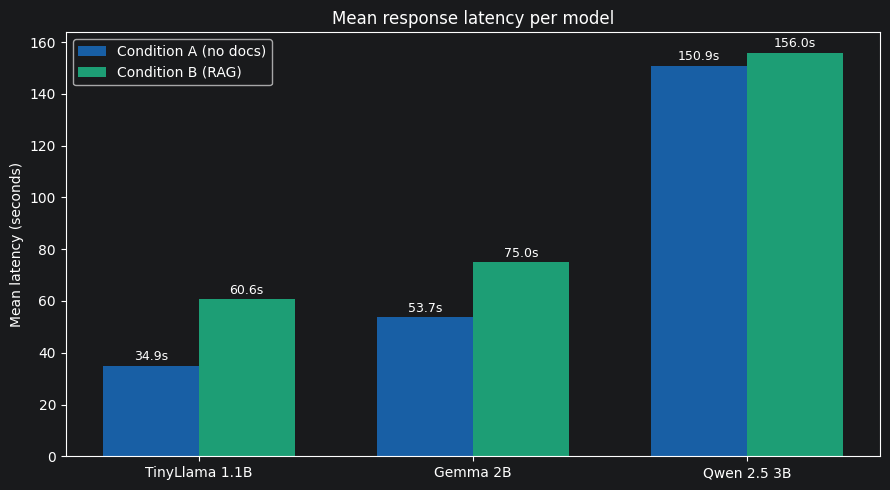

In [4]:
lat_a = [np.mean([r["latency_ms"] for r in all_data[m]["results"] if r["condition"]=="A"]) / 1000 for m in models]
lat_b = [np.mean([r["latency_ms"] for r in all_data[m]["results"] if r["condition"]=="B"]) / 1000 for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_a = ax.bar(x - width/2, lat_a, width, label="Condition A (no docs)", color="#185FA5")
bars_b = ax.bar(x + width/2, lat_b, width, label="Condition B (RAG)", color="#1D9E75")

# Add value labels on top of each bar
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=9)

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Mean latency (seconds)")
ax.set_title("Mean response latency per model")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.tight_layout()
plt.show()

## 2b. RAG Overhead

In [5]:
# RAG overhead - How much extra latency the retrieval pipeline adds per model
print(f"{'Model':<20} {'Cond A (s)':>12} {'Cond B (s)':>12} {'Overhead (s)':>14} {'Overhead %':>12}")
print("-" * 65)

for m, la, lb in zip(models, lat_a, lat_b):
    overhead_s = lb - la
    overhead_pct = 100 * overhead_s / la
    print(f"{m:<20} {la:>12.1f} {lb:>12.1f} {overhead_s:>14.1f} {overhead_pct:>11.1f}%")

Model                  Cond A (s)   Cond B (s)   Overhead (s)   Overhead %
-----------------------------------------------------------------
TinyLlama 1.1B               34.9         60.6           25.7        73.7%
Gemma 2B                     53.7         75.0           21.3        39.6%
Qwen 2.5 3B                 150.9        156.0            5.1         3.4%


## 3. Peak memory usage

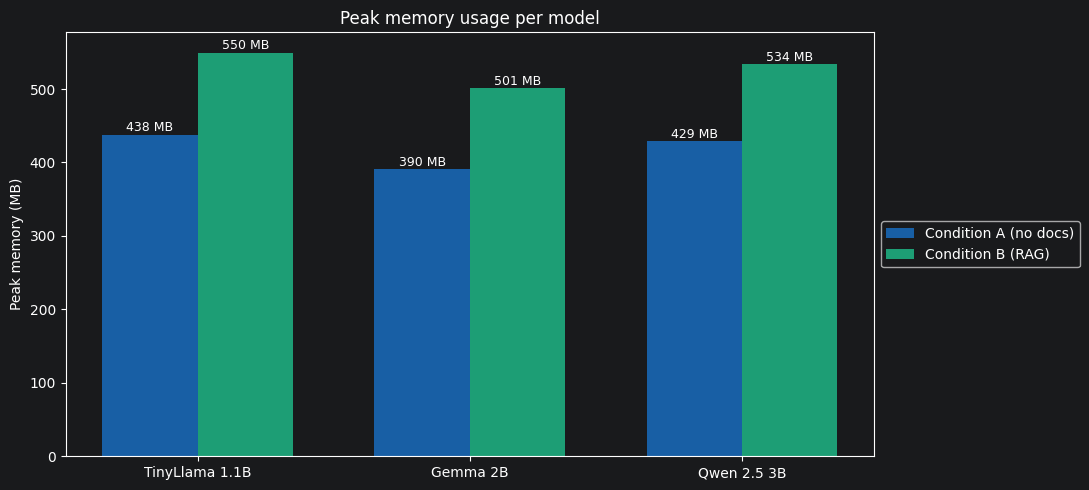

In [6]:
mem_a = [np.mean([r["peak_memory_mb"] for r in all_data[m]["results"] if r["condition"]=="A"]) for m in models]
mem_b = [np.mean([r["peak_memory_mb"] for r in all_data[m]["results"] if r["condition"]=="B"]) for m in models]

fig, ax = plt.subplots(figsize=(11, 5))

bars_a = ax.bar(x - width/2, mem_a, width, label="Condition A (no docs)", color="#185FA5")
bars_b = ax.bar(x + width/2, mem_b, width, label="Condition B (RAG)", color="#1D9E75")

# Add value labels on top of each bar
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.0f} MB", ha="center", va="bottom", fontsize=9)

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.0f} MB", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Peak memory (MB)")
ax.set_title("Peak memory usage per model")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## 4. Accuracy Summary

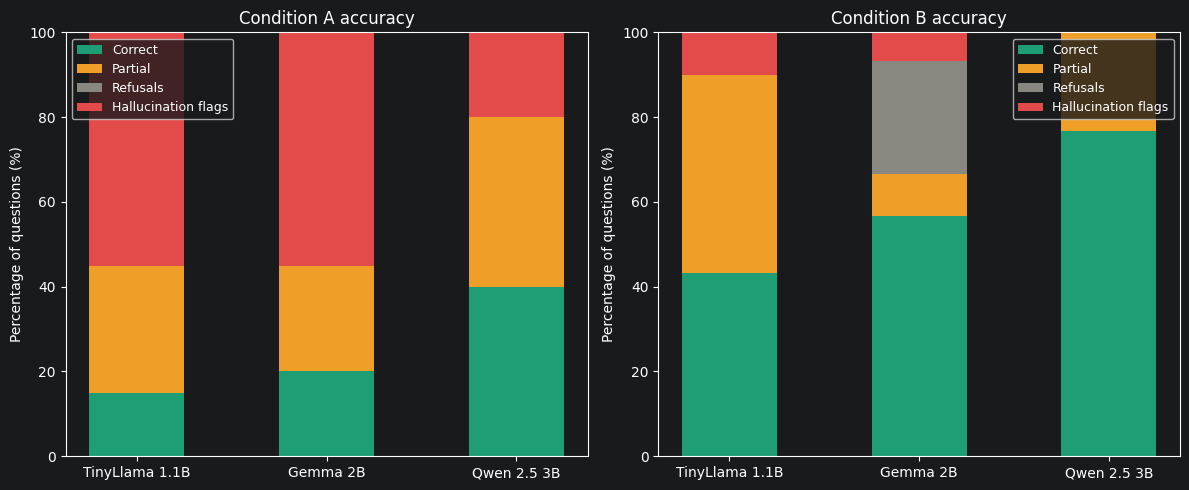

In [7]:
def get_counts(model_results, condition):
    results = [r for r in model_results if r["condition"] == condition]
    total = len(results)

    # Use manual_score
    def final_score(r):
        return r["scores"]["manual_score"] if r["scores"]["manual_score"] is not None else r["scores"]["accuracy"]

    correct = sum(1 for r in results if final_score(r) == "correct")
    partial = sum(1 for r in results if final_score(r) == "partial")
    refused = sum(1 for r in results if r["scores"]["refusal"])
    halluc  = sum(1 for r in results if r["scores"]["hallucination"])
    return total, correct, partial, refused, halluc

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, cond in enumerate(["A", "B"]):
    ax = axes[idx]
    correct_vals, partial_vals, refused_vals, halluc_vals = [], [], [], []

    for m in models:
        total, correct, partial, refused, halluc = get_counts(all_data[m]["results"], cond)
        correct_vals.append(100 * correct / total)
        partial_vals.append(100 * partial / total)
        refused_vals.append(100 * refused / total)
        halluc_vals.append(100 * halluc / total)

    # Stack correct, partial, refusals, hallucinations
    ax.bar(x, correct_vals, width=0.5, label="Correct", color="#1D9E75")
    ax.bar(x, partial_vals, width=0.5, bottom=correct_vals, label="Partial", color="#EF9F27")
    ax.bar(x, refused_vals, width=0.5,
           bottom=[c + p for c, p in zip(correct_vals, partial_vals)],
           label="Refusals", color="#888780")
    ax.bar(x, halluc_vals, width=0.5,
           bottom=[c + p + r for c, p, r in zip(correct_vals, partial_vals, refused_vals)],
           label="Hallucination flags", color="#E24B4A")

    ax.set_title(f"Condition {cond} accuracy")
    ax.set_ylabel("Percentage of questions (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Document Grounding (Condition B only)

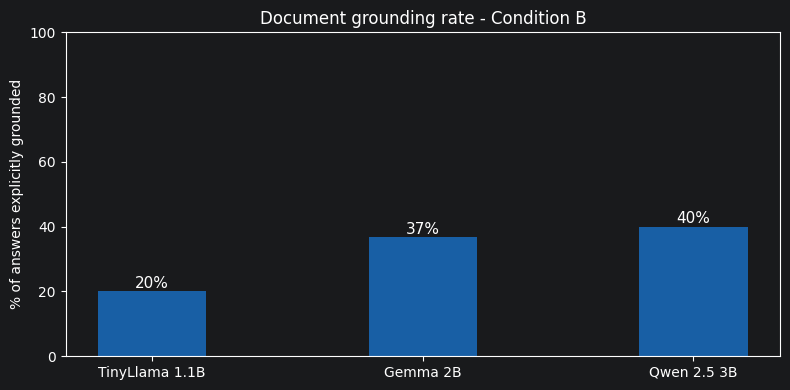

In [8]:
# Calculate the percentage of Condition B answers that explicitly
# referenced the retrieved context using grounding phrases
grounded_vals = []
for m in models:
    cond_b = [r for r in all_data[m]["results"] if r["condition"] == "B"]
    grounded = sum(1 for r in cond_b if r["scores"]["grounding"] == "grounded")
    grounded_vals.append(100 * grounded / len(cond_b))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(models, grounded_vals, color="#185FA5", width=0.4)

ax.set_ylabel("% of answers explicitly grounded")
ax.set_title("Document grounding rate - Condition B")
ax.set_ylim(0, 100)

# Add percentage labels above each bar
for bar, val in zip(bars, grounded_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.0f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## 6. Hallucination Rate

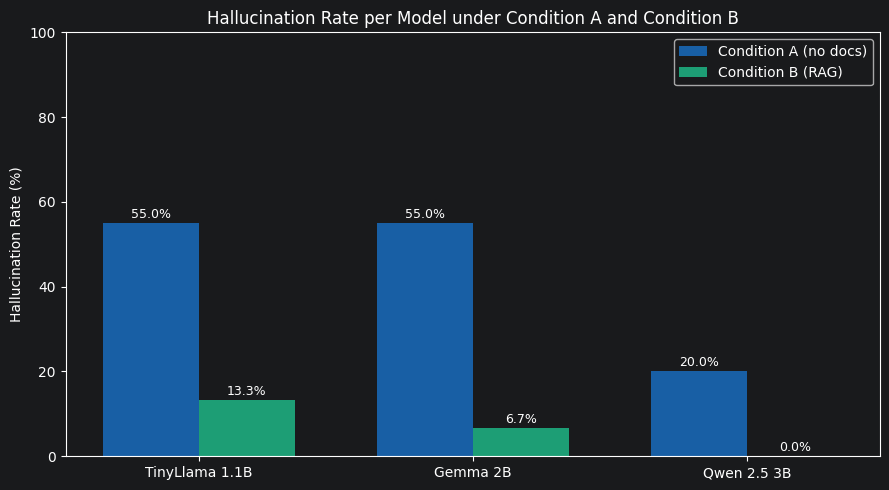

In [9]:
# Calculate hallucination rate for each model under both conditions

halluc_a = []
halluc_b = []

for m in models:
    # Split results by condition for this model
    a = [r for r in all_data[m]["results"] if r["condition"] == "A"]
    b = [r for r in all_data[m]["results"] if r["condition"] == "B"]

    # Count hallucinated responses and convert to percentage
    halluc_a.append(100 * sum(1 for r in a if r["scores"]["hallucination"]) / len(a))
    halluc_b.append(100 * sum(1 for r in b if r["scores"]["hallucination"]) / len(b))

# Use the same x positions and bar width as the other charts for consistency
fig, ax = plt.subplots(figsize=(9, 5))

bars_a = ax.bar(x - width/2, halluc_a, width, label="Condition A (no docs)", color="#185FA5")
bars_b = ax.bar(x + width/2, halluc_b, width, label="Condition B (RAG)", color="#1D9E75")

# Add percentage labels on top of each bar
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Hallucination Rate (%)")
ax.set_title("Hallucination Rate per Model under Condition A and Condition B")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## 7. Summary table

In [10]:
# Print a summary table showing all five key metrics across both conditions for each model
def final_score(r):
    return r["scores"]["manual_score"] if r["scores"]["manual_score"] is not None else r["scores"]["accuracy"]

print(f"{'Model':<20} {'A Correct':>10} {'A Partial':>10} {'A Wrong':>10} {'A Hallucination':>10} | "
      f"{'B Correct':>10} {'B Partial':>10} {'B Wrong':>10} {'B Refused':>10} {'B Hallucination':>10} {'B Grounded':>11}")
print("-" * 125)

for m in models:
    results = all_data[m]["results"]
    a = [r for r in results if r["condition"] == "A"]
    b = [r for r in results if r["condition"] == "B"]

    a_correct = f"{sum(1 for r in a if final_score(r) == 'correct')}/{len(a)}"
    a_partial  = f"{sum(1 for r in a if final_score(r) == 'partial')}/{len(a)}"
    a_wrong    = f"{sum(1 for r in a if final_score(r) == 'wrong')}/{len(a)}"
    a_halluc   = f"{sum(1 for r in a if r['scores']['hallucination'])}/{len(a)}"

    b_correct  = f"{sum(1 for r in b if final_score(r) == 'correct')}/{len(b)}"
    b_partial  = f"{sum(1 for r in b if final_score(r) == 'partial')}/{len(b)}"
    b_wrong    = f"{sum(1 for r in b if final_score(r) == 'wrong')}/{len(b)}"
    b_refused  = f"{sum(1 for r in b if r['scores']['refusal'])}/{len(b)}"
    b_halluc   = f"{sum(1 for r in b if r['scores']['hallucination'])}/{len(b)}"
    b_ground   = f"{sum(1 for r in b if r['scores']['grounding'] == 'grounded')}/{len(b)}"

    print(f"{m:<20} {a_correct:>10} {a_partial:>10} {a_wrong:>10} {a_halluc:>10} | "
          f"{b_correct:>10} {b_partial:>10} {b_wrong:>10} {b_refused:>10} {b_halluc:>10} {b_ground:>11}")

Model                 A Correct  A Partial    A Wrong A Hallucination |  B Correct  B Partial    B Wrong  B Refused B Hallucination  B Grounded
-----------------------------------------------------------------------------------------------------------------------------
TinyLlama 1.1B             3/20       6/20      11/20      11/20 |      13/30      14/30       3/30       0/30       4/30        6/30
Gemma 2B                   4/20       5/20      11/20      11/20 |      17/30       3/30      10/30       8/30       2/30       11/30
Qwen 2.5 3B                8/20       8/20       4/20       4/20 |      23/30       7/30       0/30       0/30       0/30       12/30


## 8. Model Scoring

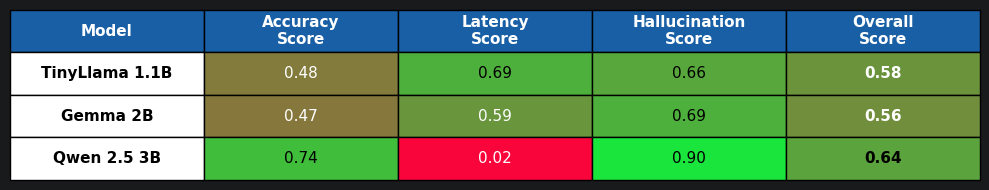

In [13]:
import matplotlib.pyplot as plt
import numpy as np

score_rows = []
score_nums = []

for m in models:
    results = all_data[m]["results"]
    a = [r for r in results if r["condition"] == "A"]
    b = [r for r in results if r["condition"] == "B"]

    # Correct counts as 1.0, partial counts as 0.5
    a_correct = sum(1 for r in a if final_score(r) == 'correct') / len(a)
    a_partial = sum(1 for r in a if final_score(r) == 'partial') / len(a)
    b_correct = sum(1 for r in b if final_score(r) == 'correct') / len(b)
    b_partial = sum(1 for r in b if final_score(r) == 'partial') / len(b)

    # Renamed to avoid clashing with lat_a/lat_b lists defined in the latency cell
    mean_lat_a = np.mean([r["latency_ms"] for r in a]) / 1000
    mean_lat_b = np.mean([r["latency_ms"] for r in b]) / 1000
    max_lat = 156.0

    halluc_a = sum(1 for r in a if r['scores']['hallucination']) / len(a)
    halluc_b = sum(1 for r in b if r['scores']['hallucination']) / len(b)

    # Each score is averaged across both conditions
    # Latency score is inverted so that higher means faster
    accuracy_score = ((a_correct * 1.0 + a_partial * 0.5) + (b_correct * 1.0 + b_partial * 0.5)) / 2
    latency_score  = 1 - ((mean_lat_a + mean_lat_b) / 2) / max_lat
    halluc_score   = 1 - (halluc_a + halluc_b) / 2

    # Weighted overall: accuracy 50%, hallucination 30%, latency 20%
    overall = round((accuracy_score * 0.5) + (halluc_score * 0.3) + (latency_score * 0.2), 2)

    score_rows.append([m, f"{accuracy_score:.2f}", f"{latency_score:.2f}", f"{halluc_score:.2f}", f"{overall:.2f}"])
    score_nums.append([accuracy_score, latency_score, halluc_score, overall])


def green_red_scale(ratio):
    r = int(255 * (1 - ratio))
    g = int(255 * ratio)
    return f"#{r:02x}{g:02x}{60:02x}"

def text_color(ratio):
    r = int(255 * (1 - ratio))
    g = int(255 * ratio)
    luminance = 0.299 * r + 0.587 * g + 0.114 * 60
    return "white" if luminance < 128 else "black"


score_cols = ["Model", "Accuracy\nScore", "Latency\nScore", "Hallucination\nScore", "Overall\nScore"]


score_colours = []
for nums in score_nums:
    row_c = ["#ffffff"]
    for v in nums:
        row_c.append(green_red_scale(v))
    score_colours.append(row_c)

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis("off")

table = ax.table(
    cellText=score_rows,
    colLabels=score_cols,
    cellColours=score_colours,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Header row styling
for j in range(len(score_cols)):
    cell = table[0, j]
    cell.set_facecolor("#185FA5")
    cell.get_text().set_color("white")
    cell.get_text().set_fontweight("bold")
    cell.get_text().set_fontsize(11)

# Bold model name and overall score
for i, nums in enumerate(score_nums):
    table[i+1, 0].get_text().set_fontweight("bold")
    table[i+1, 0].get_text().set_color("black")
    for j, v in enumerate(nums):
        table[i+1, j+1].get_text().set_color(text_color(v))
    table[i+1, len(score_cols)-1].get_text().set_fontweight("bold")

plt.tight_layout()
plt.show()